### Imports

In [1]:
!pip install transformers

In [2]:
import torch
from tqdm.notebook import tqdm

from torch.utils.data import TensorDataset
# from google.colab import drive
import pandas as pd

import nltk
import re
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.corpus import stopwords
from  nltk.stem import SnowballStemmer

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from transformers import BertTokenizer

from transformers import BertForSequenceClassification
import numpy as np

In [4]:
import random

seed_val = 17
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

### Load Data

In [5]:
# drive.mount('/content/drive')

In [6]:
# path = '/content/drive/MyDrive/Memoria_Risk_Classification/Datasets/'
path = '/kaggle/input/tosdr-split-data/'
df = pd.read_csv(path + 'TOSDR_SPLIT_DATA (1).csv')

In [7]:
def delete_text(text):
  sufijos_a_eliminar = ['terms of service', 'privacy policy', 'privacy policy agreement', 'terms & conditions', 'terms of use', 'coinbase user agreement']
  text = text.lower()
  for sufijo in sufijos_a_eliminar:
    if text.endswith(sufijo):
      text = text.rstrip(sufijo)
  return text

df['text'] = df['text'].apply(lambda x: delete_text(x))

In [8]:
df['text'].values[0]

'any errors or defects will be corrected'

In [9]:
print(df.head())
print(df.shape)

   Unnamed: 0    service                                       privacy_text  \
0           0  1password  The service does not guarantee that software e...   
1           1  1password  This service provides archives of their terms ...   
2           2  1password  The services will notify users if personal dat...   
3           3  1password  This service assumes no liability for any loss...   
4           4  1password  Users should revisit the terms periodically, a...   

                             case_link  label  \
0   https://edit.tosdr.org/points/6727      1   
1   https://edit.tosdr.org/points/6728      0   
2  https://edit.tosdr.org/points/13405      0   
3   https://edit.tosdr.org/points/6724      0   
4   https://edit.tosdr.org/points/6723      0   

                                                text idioma  clase data_type  
0            any errors or defects will be corrected     en      1      test  
1  the change log section below is not a part of ...     en      0     t

In [10]:
df['label'].value_counts()

label
0    2861
1    1529
Name: count, dtype: int64

In [11]:
df['clase'] = df['label']

In [12]:
df.head()

,Unnamed: 0,service,privacy_text,case_link,label,text,idioma,clase,data_type
0,0,1password,The service does not guarantee that software e...,https://edit.tosdr.org/points/6727,1,any errors or defects will be corrected,en,1,test
1,1,1password,This service provides archives of their terms ...,https://edit.tosdr.org/points/6728,0,the change log section below is not a part of ...,en,0,train
2,2,1password,The services will notify users if personal dat...,https://edit.tosdr.org/points/13405,0,"in an event of a breach, we recognize our res...",en,0,test
3,3,1password,This service assumes no liability for any loss...,https://edit.tosdr.org/points/6724,0,"agilebits, inc., its directors, employees, par...",en,0,train
4,4,1password,"Users should revisit the terms periodically, a...",https://edit.tosdr.org/points/6723,0,"at our discretion, we may make changes to this...",en,0,train


In [13]:
df.groupby(['clase', 'data_type']).count()

Unnamed: 0  service  privacy_text  case_link  label  text  \
clase data_type                                                              
0     test              286      286           286        286    286   286   
      train            2317     2317          2317       2317   2317  2317   
      val               258      258           258        258    258   258   
1     test              153      153           153        153    153   153   
      train            1238     1238          1238       1238   1238  1238   
      val               138      138           138        138    138   138   

                 idioma  
clase data_type          
0     test          286  
      train        2317  
      val           258  
1     test          153  
      train        1238  
      val           138

### Clean Text

In [14]:
stop_words = stopwords.words("english")

stemmer = SnowballStemmer("english")

def clean_text(text):
  TEXT_CLEANING_RE = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
  TEXT_CLEANING_RE_EXTRA = "[^\w\s]"
  text = re.sub(TEXT_CLEANING_RE, ' ', str(text).lower()).strip()
  text = re.sub(TEXT_CLEANING_RE_EXTRA, ' ', str(text).lower()).strip()
  return text

def preprocess(text,cleaning=True,stopwords=True,stemming=True):
    if cleaning:
      text = clean_text(text)
    tokens = []
    for token in text.split():
        if (not stopwords) or (stopwords and (token not in stop_words)):
            if stemming:
                tokens.append(stemmer.stem(token))
            else:
                tokens.append(token)
    return " ".join(tokens)

In [15]:
# df['cleaned_text'] = df['text'].apply(lambda x: preprocess(x))

### Hiperparametros

In [16]:
DROPOUT = 0.1
BATCH_SIZE = 16
LEARNING_RATE = 1e-5
EPSILON = 1e-8
EPOCH = 5

SEED = 17
NUM_LABELS = 2
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128

### Prepare input for BERT

In [17]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME,
                                          do_lower_case=True)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [18]:

encoded_data_train = tokenizer.batch_encode_plus(
    list(df[df.data_type=='train'].text.values),
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    pad_to_max_length=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

encoded_data_val = tokenizer.batch_encode_plus(
    list(df[df.data_type=='val'].text.values),
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    pad_to_max_length=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

encoded_data_test = tokenizer.batch_encode_plus(
    list(df[df.data_type=='test'].text.values),
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    pad_to_max_length=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

input_ids_train = encoded_data_train['input_ids']
attention_masks_train = encoded_data_train['attention_mask']
token_type_ids_train = encoded_data_train['token_type_ids']
labels_train = torch.tensor(df[df.data_type=='train'].clase.values)

input_ids_val = encoded_data_val['input_ids']
attention_masks_val = encoded_data_val['attention_mask']
token_type_ids_val = encoded_data_val['token_type_ids']
labels_val = torch.tensor(df[df.data_type=='val'].clase.values)

input_ids_test = encoded_data_test['input_ids']
attention_masks_test = encoded_data_test['attention_mask']
token_type_ids_test = encoded_data_test['token_type_ids']
labels_test = torch.tensor(df[df.data_type=='test'].clase.values)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2618: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(


In [19]:
dataset_train = TensorDataset(input_ids_train, attention_masks_train, token_type_ids_train, labels_train)
dataset_val = TensorDataset(input_ids_val, attention_masks_val, token_type_ids_val, labels_val)
dataset_test = TensorDataset(input_ids_test, attention_masks_test, token_type_ids_test, labels_test)

In [20]:
len(dataset_train), len(dataset_val), len(dataset_test)

(3555, 396, 439)

### Model Aquitecture

In [21]:
from transformers import AutoConfig

configuration = AutoConfig.from_pretrained(MODEL_NAME)
configuration.num_labels = NUM_LABELS
configuration.output_attentions = False
configuration.output_hidden_states = False
configuration.classifier_dropout = DROPOUT

In [22]:
model = BertForSequenceClassification.from_pretrained(MODEL_NAME,
                                                      config = configuration)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

dataloader_train = DataLoader(dataset_train,
                              sampler=RandomSampler(dataset_train),
                              batch_size=BATCH_SIZE)

dataloader_validation = DataLoader(dataset_val,
                                   sampler=SequentialSampler(dataset_val),
                                   batch_size=BATCH_SIZE)

dataloader_test = DataLoader(dataset_test,
                            sampler=SequentialSampler(dataset_test),
                            batch_size=BATCH_SIZE)

In [24]:
from transformers import AdamW, get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(),
                  lr=LEARNING_RATE,
                  eps=EPSILON)

/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [25]:
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=len(dataloader_train)*EPOCH)

In [26]:
from sklearn.metrics import f1_score, precision_recall_fscore_support


def metrics(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return precision_recall_fscore_support(labels_flat, preds_flat, average='macro')

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(device)

cuda


In [28]:
pesos = compute_class_weight('balanced', classes = np.unique(df.label.values), y = df.label.values)
class_weights = {
    0: pesos[0],
    1: pesos[1]
}
weights = torch.tensor([pesos[0], pesos[1]], dtype=torch.float32).to(device)

In [29]:
weights.view(-1)

tensor([0.7672, 1.4356], device='cuda:0')

In [30]:
def evaluate(dataloader_val):

    model.eval()

    loss_val_total = 0
    predictions, true_vals = [], []

    for batch in dataloader_val:

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  'token_type_ids': batch[2],
                  'labels':         batch[3]
                 }

        with torch.no_grad():
            outputs = model(**inputs)


        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        loss = criterion(outputs['logits'], inputs['labels'])


        # loss = outputs[0]
        # logits = outputs[1]
        logits = outputs['logits']
        loss_val_total += loss.item()

        logits = logits.detach().cpu().numpy()
        label_ids = inputs['labels'].cpu().numpy()
        predictions.append(logits)
        true_vals.append(label_ids)

    loss_val_avg = loss_val_total/len(dataloader_val)

    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)

    return loss_val_avg, predictions, true_vals

In [31]:
# https://stackoverflow.com/questions/71998978/early-stopping-in-pytorch

class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [32]:
path_model = '/content/drive/MyDrive/Memoria_Group_Classification/Modelos/'

train_loss_history = []
val_loss_history = []
early_stopper = EarlyStopper(patience=2, min_delta=10)

for epoch in tqdm(range(1, EPOCH+1)):

    model.train()

    loss_train_total = 0

    progress_bar = tqdm(dataloader_train, desc='Epoch {:1d}'.format(epoch), leave=False, disable=False)
    for batch in progress_bar:

        model.zero_grad()

        batch = tuple(b.to(device) for b in batch)

        inputs = {'input_ids':      batch[0],
                  'attention_mask': batch[1],
                  'token_type_ids': batch[2],
                  'labels':         batch[3]
                 }

        outputs = model(**inputs)

        criterion = torch.nn.CrossEntropyLoss(weight=weights)
        loss = criterion(outputs['logits'], inputs['labels'])

        loss_train_total += loss.item()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item()/len(batch))})

    torch.save(model.state_dict(), f'finetuned_V2_BERT_epoch_{epoch}.model')

    tqdm.write(f'\nEpoch {epoch}')

    loss_train_avg = loss_train_total/len(dataloader_train)
    tqdm.write(f'Training loss: {loss_train_avg}')

    val_loss, predictions, true_vals = evaluate(dataloader_validation)
    val_metrics = metrics(predictions, true_vals)

    train_loss_history.append(loss_train_avg)
    val_loss_history.append(val_loss)

    tqdm.write(f'Validation loss: {val_loss}')
    tqdm.write(f'Precision : {val_metrics[0]} - Recall : {val_metrics[1]} - F1 Score : {val_metrics[2]} (Validation)')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 1
Training loss: 0.5957916353582802
Validation loss: 0.5279613673686981
Precision : 0.7398927340058741 - Recall : 0.7638186720593192 - F1 Score : 0.7374332849724605 (Validation)


Epoch 2:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 2
Training loss: 0.42499553783057514
Validation loss: 0.3944431173801422
Precision : 0.8057929724596391 - Recall : 0.8255813953488372 - F1 Score : 0.8121951219512196 (Validation)


...


Epoch 3
Training loss: 0.302510385589482
Validation loss: 0.3529266768693924
Precision : 0.8550622284998535 - Recall : 0.8741995281429054 - F1 Score : 0.8622514749514034 (Validation)


Epoch 4:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 4
Training loss: 0.2167576270620652
Validation loss: 0.3724113702774048
Precision : 0.8647194910352805 - Recall : 0.8542298618132793 - F1 Score : 0.8590064942463256 (Validation)


Epoch 5:   0%|          | 0/223 [00:00<?, ?it/s]


Epoch 5
Training loss: 0.17305260908376477
Validation loss: 0.35366523087024687
Precision : 0.8634146341463416 - Recall : 0.8766430738119313 - F1 Score : 0.869047619047619 (Validation)


### Evaluation Metrics

In [33]:
def get_confusion_matrix(y_true, y_pred, class_names):
  fig, ax = plt.subplots(figsize=(6, 6))
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
  plt.rcParams.update({'font.size': 9})
  plt.rc('xtick', labelsize=9)
  plt.rc('ytick', labelsize=9)
  plt.xlabel('Predicted Label', fontsize=9)
  plt.ylabel('True Label', fontsize=9)
  disp = disp.plot(ax=ax,cmap=plt.cm.Greens, xticks_rotation='vertical')
  plt.show()

In [34]:
def plot_metrics(train_history, val_history, metrics = ['accuracy', 'F1']):

    plt.plot(train_history, color='blue', label='train')
    plt.plot(val_history,
             color='orange', label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, plt.ylim()[1]])
    plt.legend();

In [35]:
_, predictions, true_vals = evaluate(dataloader_validation)
y_pred = predictions.argmax(axis=1)

In [36]:
print(classification_report(labels_val.numpy(), y_pred, target_names=['neutral','bad']))

              precision    recall  f1-score   support

     neutral       0.93      0.88      0.90       258
         bad       0.80      0.87      0.83       138

    accuracy                           0.88       396
   macro avg       0.86      0.88      0.87       396
weighted avg       0.88      0.88      0.88       396



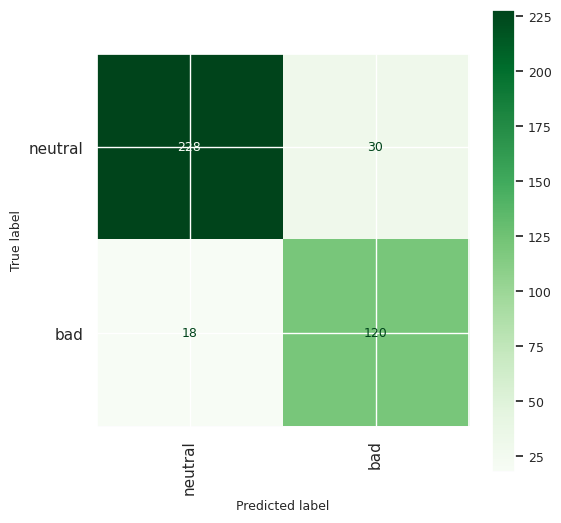

In [37]:
get_confusion_matrix(labels_val.numpy(), y_pred, ['neutral','bad'])

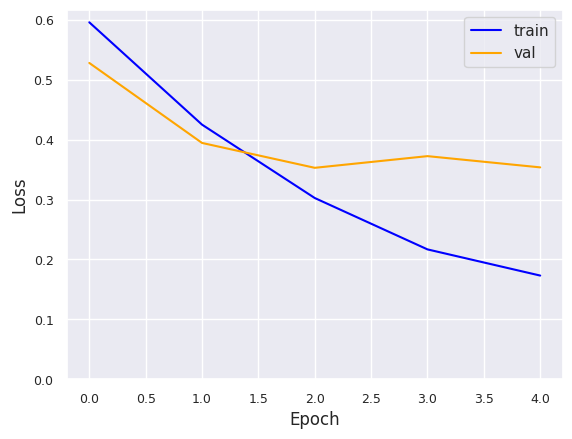

In [38]:
plot_metrics(train_loss_history, val_loss_history)

In [39]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                      num_labels=2,
                                                      output_attentions=False,
                                                      output_hidden_states=False)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [40]:
epoch = 3
model.load_state_dict(torch.load(f'finetuned_V2_BERT_epoch_{epoch}.model', map_location=torch.device('cuda')))

<All keys matched successfully>

In [41]:
_, predictions, true_vals = evaluate(dataloader_validation)
y_pred = predictions.argmax(axis=1)

In [42]:
print(classification_report(labels_val.numpy(), y_pred, target_names=['neutral','bad']))

              precision    recall  f1-score   support

     neutral       0.93      0.86      0.90       258
         bad       0.78      0.88      0.83       138

    accuracy                           0.87       396
   macro avg       0.86      0.87      0.86       396
weighted avg       0.88      0.87      0.87       396



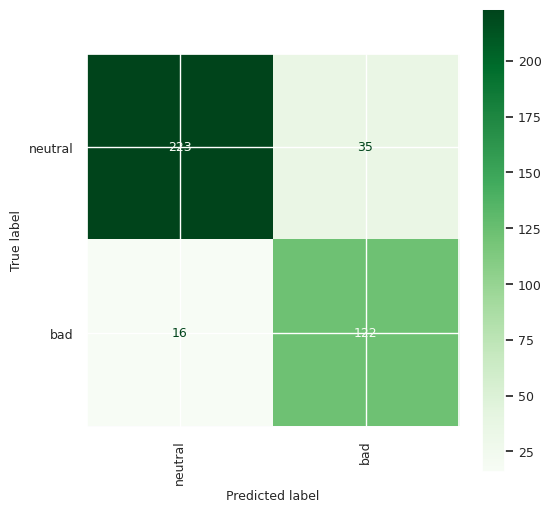

In [43]:
get_confusion_matrix(labels_val.numpy(), y_pred, ['neutral','bad'])

In [62]:
# path = '/content/drive/MyDrive/Memoria_Risk_Classification/Modelos/BEST MODEL/'
# torch.save(model.state_dict(), path + f'finetuned_V2_BERT_epoch_{epoch}_BEST_MODEL.model')

In [44]:
_, predictions, true_vals = evaluate(dataloader_test)
y_pred = predictions.argmax(axis=1)

In [45]:
predictions[0]

array([ 0.5675691, -0.9442176], dtype=float32)

In [47]:
softmax = torch.nn.Softmax(dim=0)
output = [softmax(torch.from_numpy(logit)) for logit in predictions]

In [48]:
test_labels = []
for _, _, _, labels in dataloader_test:
    for x in labels:
        test_labels.append(x.item())

In [49]:
print(classification_report(test_labels, y_pred, target_names=['neutral','bad']))

              precision    recall  f1-score   support

     neutral       0.90      0.87      0.88       286
         bad       0.77      0.81      0.79       153

    accuracy                           0.85       439
   macro avg       0.83      0.84      0.84       439
weighted avg       0.85      0.85      0.85       439



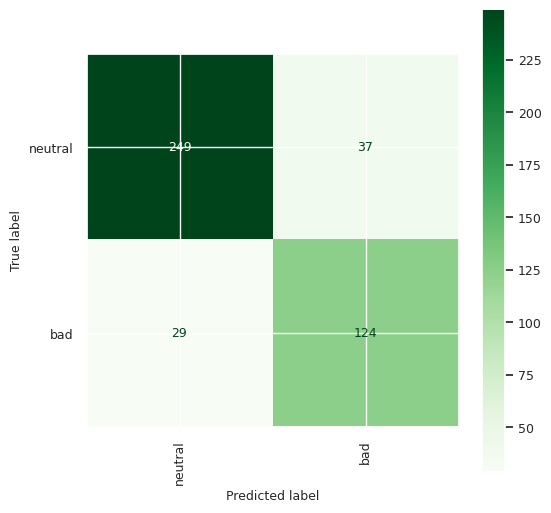

In [50]:
get_confusion_matrix(test_labels, y_pred, ['neutral','bad'])

In [51]:
label_dict = ['neutral','bad']

In [52]:
predict = [label_dict[num] for num in y_pred]
real_label = [label_dict[num] for num in df[df.data_type=='test'].clase.values]

In [53]:
import pandas as pd

df_text = pd.DataFrame({
    'text': df[df.data_type=='test'].text.values,
    'clase': predict,
    'real_label': real_label,
    'probabilidades': output
})

In [54]:
df_text.head()

,text,clase,real_label,probabilidades
0,any errors or defects will be corrected,neutral,bad,"[tensor(0.8193), tensor(0.1807)]"
1,"in an event of a breach, we recognize our res...",neutral,neutral,"[tensor(0.6556), tensor(0.3444)]"
2,we do so through the processing of transaction...,bad,bad,"[tensor(0.0294), tensor(0.9706)]"
3,we follow the digital advertising alliance’s (...,bad,neutral,"[tensor(0.4953), tensor(0.5047)]"
4,you agree not to create an account using a fal...,neutral,neutral,"[tensor(0.9589), tensor(0.0411)]"


In [55]:
# from google.colab import files

df_text.to_csv('predicciones_test_set_Risk.csv', index=False)
# files.download('predicciones_test_set_Risk.csv')

In [56]:
import pandas as pd

df_dos = pd.read_csv('predicciones_test_set_Risk.csv')

In [68]:
# clase = 'neutral'
# df_dos[(df_dos['clase'] == clase) & (df_dos['real_label'] == clase)].values[2]

df_dos[(df_dos['clase'] == clase) & (df_dos['real_label'] == clase)].values[2]

array(['You agree not to create an Account using a false identity or alias or if you previously have been banned from using any of the Services.  Terms and Conditions',
       'neutral', 'neutral', 'tensor([0.9741, 0.0259])'], dtype=object)